In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error,mean_absolute_error,r2_score
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Question 1

In [129]:
df=pd.read_csv("Teen_Mental_Health_Dataset.csv")
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [130]:
df=pd.get_dummies(data=df,columns=["gender","platform_usage","social_interaction_level"])
df=df.dropna()

In [131]:
x=df.drop("depression_label",axis=1)
y=df["depression_label"]
size=[0.05,0.1,0.15,0.2,0.25]
d={"model":[],"accuracy":[],"test_size":[]}
for i in size:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=42)
    d["model"].append("KNN")
    d["test_size"].append(i)
    knn=KNeighborsClassifier(n_neighbors=29)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    d["accuracy"].append(accuracy_score(y_test,y_pred))

    d["model"].append("DT")
    d["test_size"].append(i)
    dt=DecisionTreeClassifier(criterion='entropy',max_depth=4,random_state=42)
    dt.fit(x_train,y_train)
    y_pred=dt.predict(x_test)
    d["accuracy"].append(accuracy_score(y_test,y_pred))

    d["model"].append("RF")
    d["test_size"].append(i)
    rf=RandomForestClassifier(n_estimators=100,criterion='entropy',random_state=42,max_depth=4)
    rf.fit(x_train,y_train)
    y_pred=rf.predict(x_test)
    d["accuracy"].append(accuracy_score(y_test,y_pred))

    
    d["model"].append("SVC")
    d["test_size"].append(i)
    svm=SVC(C=10,kernel='rbf',random_state=42)
    svm.fit(x_train,y_train)
    y_pred=svm.predict(x_test)
    d["accuracy"].append(accuracy_score(y_test,y_pred))

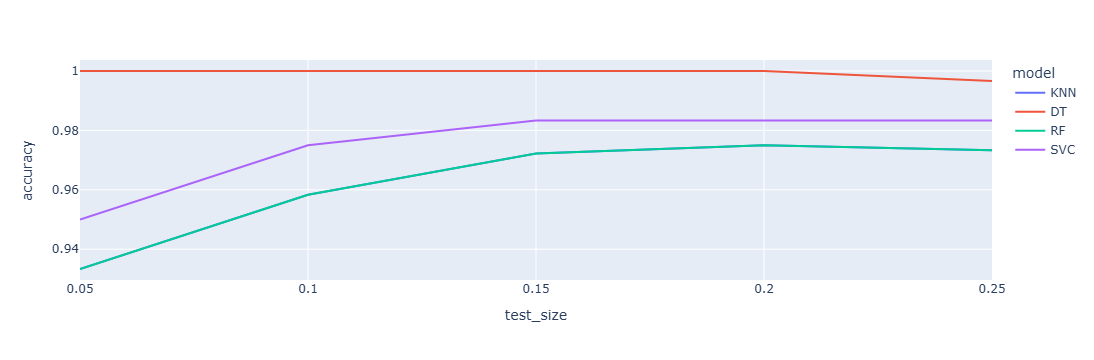

In [132]:
d=pd.DataFrame(d)
px.line(data_frame=d,x="test_size",y="accuracy",color="model")

In [133]:
result=d.groupby("model")["accuracy"].max().reset_index()
result.head(1)

,model,accuracy
0,DT,1.0


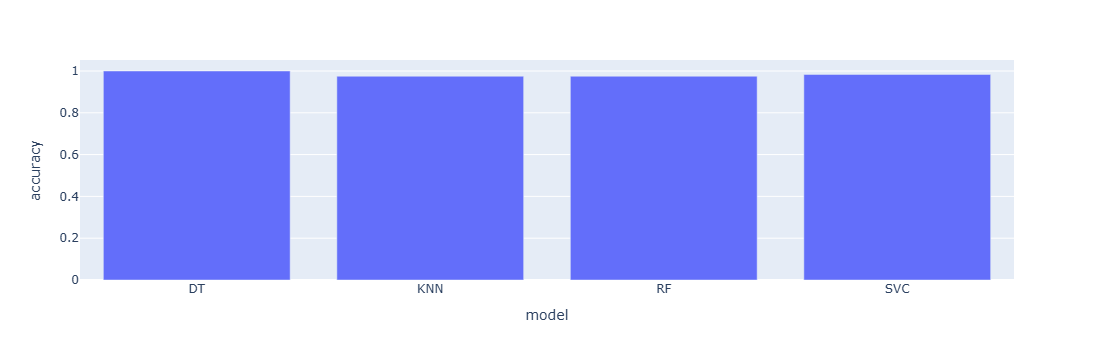

In [134]:
px.bar(data_frame=result,x="model",y="accuracy")

# Question 2

In [135]:
df=pd.read_csv("created_house_price_prediction.csv")
df

,Area,Bedrooms,Bathrooms,Garage,YearBuilt,Location,Price
0,8000.0,3.0,2.0,1.0,2004.0,Lagos,105402678.0
1,8100.0,2.0,2.0,1.0,2013.0,Kaduna,62530695.0
2,8200.0,2.0,1.0,0.0,2023.0,Kano,71488309.0
3,8300.0,3.0,1.0,0.0,2006.0,Kano,70608894.0
4,8400.0,3.0,2.0,1.0,2003.0,Lagos,107029977.0
...,...,...,...,...,...,...,...
2045,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2046,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2047,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2048,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [136]:
df=df.dropna()
df=pd.get_dummies(df,columns=["Location"])

In [137]:
x=df.drop("Price",axis=1)
y=df.Price
degree=[1,2,3,4,5]
maxx=0
d=0
DD={"degree":[],"MSE":[],"score":[]}
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
for i in degree:
    poly=PolynomialFeatures(degree=i)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    model=LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred=model.predict(x_test_poly)
    DD["degree"].append(i)
    DD["MSE"].append(mean_squared_error(y_test,y_pred))
    print("MSE:",mean_squared_error(y_test,y_pred))
    score=r2_score(y_test,y_pred)
    DD["score"].append(score)

    if maxx<score:
        maxx=score
        d=i 
    

MSE: 401114139847949.25
MSE: 257161051953968.8
MSE: 125774521932174.31
MSE: 47215458395561.36
MSE: 39362651139290.88


In [138]:
DD=pd.DataFrame(DD)
DD

,degree,MSE,score
0,1,4.011141e+14,0.214250
1,2,2.571611e+14,0.496243
2,3,1.257745e+14,0.753618
3,4,4.721546e+13,0.907509
4,5,3.936265e+13,0.922892


In [139]:
print("The best Degree based on maximum r2 score is degree",d,"with R2 score:",maxx)


The best Degree based on maximum r2 score is degree 5 with R2 score: 0.922891811658237


In [140]:
size=[0.05,0.1,0.15,0.2,0.25]
D={"model":[],"test_size":[],"score":[],"MSE":[]}
for i in size:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=42)
    poly=PolynomialFeatures(degree=d)
    D["model"].append("Polynomial Regression")
    D["test_size"].append(i)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    model=LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred=model.predict(x_test_poly)
    D["MSE"].append(mean_squared_error(y_test,y_pred))
    D["score"].append(r2_score(y_test,y_pred))

    D["model"].append("Linear Regression")
    D["test_size"].append(i)
    model=LinearRegression()
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    D["MSE"].append(mean_squared_error(y_test,y_pred))
    D["score"].append(r2_score(y_test,y_pred))

In [141]:
D=pd.DataFrame(D)
D

,model,test_size,score,MSE
0,Polynomial Regression,0.05,0.935609,4.978899e+13
1,Linear Regression,0.05,0.268646,5.655044e+14
2,Polynomial Regression,0.10,0.918805,4.003019e+13
3,Linear Regression,0.10,0.178949,4.047876e+14
4,Polynomial Regression,0.15,0.924259,4.247488e+13
5,Linear Regression,0.15,0.230288,4.316472e+14
6,Polynomial Regression,0.20,0.922892,3.936265e+13
7,Linear Regression,0.20,0.214250,4.011141e+14
8,Polynomial Regression,0.25,0.920735,3.855058e+13
9,Linear Regression,0.25,0.178664,3.994572e+14


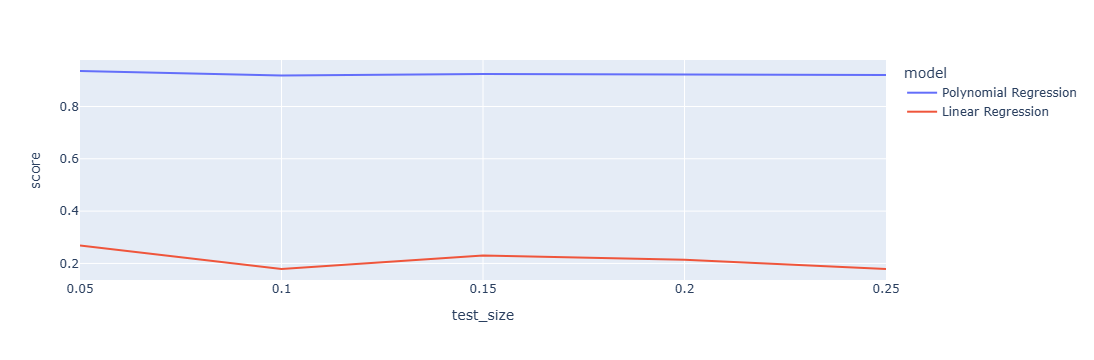

In [143]:
px.line(data_frame=D,x="test_size",y="score",color="model")

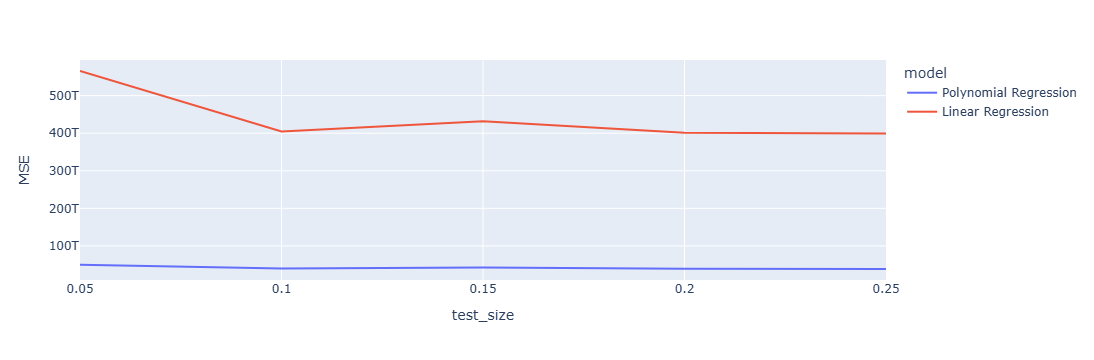

In [120]:
px.line(data_frame=D,x="test_size",y="MSE",color="model")